In [8]:
import torch

from matplotlib import pyplot as plt

In [2]:
torch.arange(100)

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
        36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53,
        54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71,
        72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89,
        90, 91, 92, 93, 94, 95, 96, 97, 98, 99])

In [34]:
def gen_data(n, T=100):
    ticks = torch.arange(T)
    
    
    per_class = n // 2
    
    x = []
    for i in range(2):
        for j in range(per_class):
            
            if i == 0:
                _x = torch.cos(8*torch.pi*ticks/(T))
            else:
                _x = torch.sin(8*torch.pi*ticks/(T))
                
            _x += torch.randn_like(_x)*0.5
            x.append(_x)

    y = [0] * per_class + [1] * per_class
    
    return torch.stack(x), torch.tensor(y)
x, y = gen_data(100)

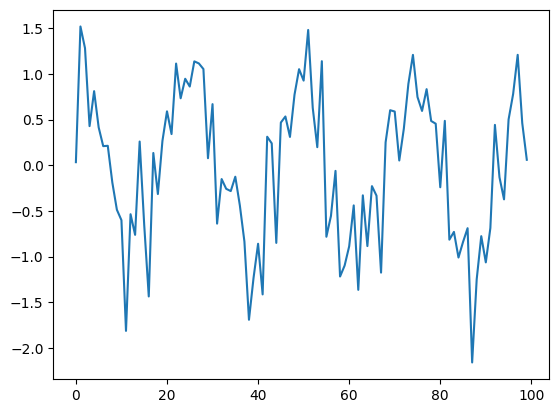

In [35]:
plt.plot(x[0, ])

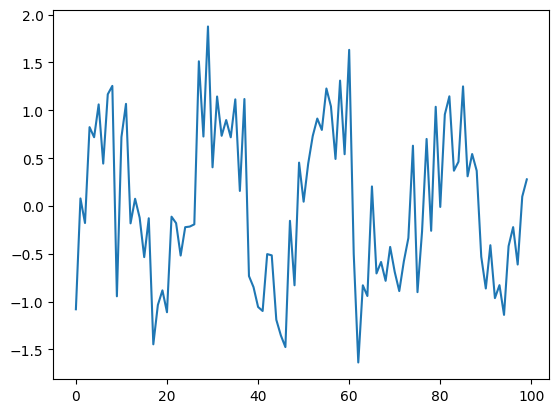

In [38]:
plt.plot(x[50, ])

In [49]:
def f(x):
    T = x.shape[1]
    ticks = torch.arange(T)
    w1 = torch.cos(8*torch.pi*ticks /(T))
    w2 = torch.sin(8*torch.pi*ticks /(T))
    
    logit_1 = x @ w1
    logit_2 = x @ w2
    
    return torch.vstack([logit_1, logit_2]).T
    
logits = f(x)

In [90]:
def counter_factual_on_x(x, target_class):
    lr = 0.1
    for i in range(1000):
        x = x.clone().requires_grad_(True)
        x.retain_grad()
        logit = f(x)[:, target_class]
        logit.backward()
        x = x + lr * x.grad
    
        with torch.no_grad():
            if torch.argmax(f(x)) == target_class:
                print("break")
                break
            
    return x.detach()


xp = x[1, :]
xh_on_x = counter_factual_on_x(xp.unsqueeze(0), 1).squeeze()
xh_on_x.shape

break


torch.Size([100])

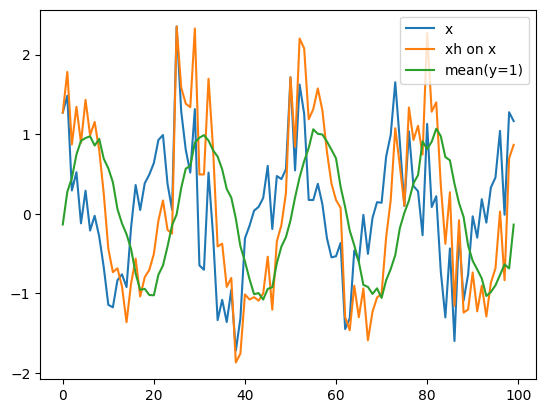

In [91]:
plt.plot(xp, label="x")
plt.plot(xh_on_x, label="xh on x")
plt.plot(x[50:].mean(dim=0), label="mean(y=1)")

plt.legend()

In [73]:
torch.fft.rfft(xp)

tensor([ 6.2148+0.0000j,  1.7387-0.2527j,  0.3762-4.1044j, -3.5256+6.3982j,
        46.9505+8.4901j,  0.4961+1.9955j, -0.6170-1.0058j,  4.4128+1.2571j,
        -3.2918-5.2706j, -2.2413+1.5352j,  3.2827-2.2611j,  3.4833+6.3060j,
         7.0416+1.8080j, -5.4091+0.0550j,  2.7960-2.5660j,  6.3429+1.0091j,
         1.0920-2.3858j, -0.8592-0.5942j,  0.5351+1.8736j,  1.2865-0.3674j,
         1.4796-5.4124j,  1.1207-0.0524j,  1.3833+1.1836j,  0.4971+4.6029j,
         0.1097+4.0295j,  5.5438-8.5425j, -3.3738+3.8388j,  0.0592+4.4614j,
         2.4873-3.3183j, -5.3874-5.6215j, -1.3685+4.3711j,  1.3121+4.1839j,
         1.6417-2.4697j, -3.2748-3.1714j,  0.5061+2.9426j, -3.0201-0.7837j,
        -1.4129-0.8556j, -4.8545-1.9276j,  4.8652-5.0381j, -2.2554-0.7895j,
         5.2456-0.0839j,  1.0572-2.9538j, -3.0249+3.4166j, -7.3361-2.5170j,
         2.0953-5.3906j,  1.4781-6.9265j,  1.8853-2.7468j, -1.5178+1.2557j,
         1.4313+0.6084j, -0.2229-4.8833j, -1.1525+0.0000j])

In [92]:
def counter_factual_on_z(x, target_class):
    lr = 0.1
    
    z = torch.fft.rfft(x)
    
    for i in range(1000):
        z = z.clone().requires_grad_(True)
        z.retain_grad()
        
        logit = f(torch.fft.irfft(z))[:, target_class]
        logit.backward()
        z = z + lr * z.grad
    
        with torch.no_grad():
            if torch.argmax(f(torch.fft.irfft(z))) == target_class:
                print("break")
                break
            
    return torch.fft.irfft(z).detach()

xh_on_z = counter_factual_on_z(xp.unsqueeze(0), 1).squeeze()

break


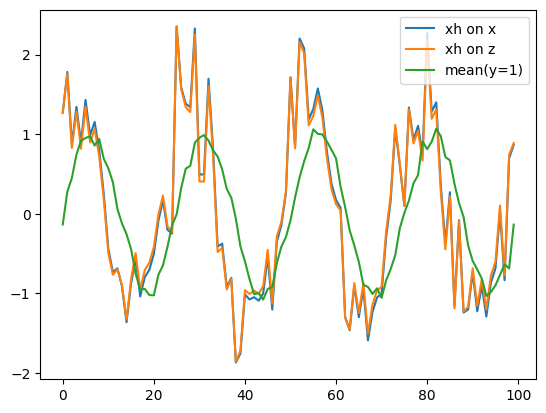

In [93]:
# plt.plot(xp, label="x")
plt.plot(xh_on_x, label="xh on x")
plt.plot(xh_on_z, label="xh on z")

plt.plot(x[50:].mean(dim=0), label="mean(y=1)")

plt.legend()

In [88]:
f(xh_on_z.unsqueeze(0))

tensor([[46.9505, 47.0097]])